In [112]:
import sys
import os
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import uuid
import warnings

warnings.filterwarnings('ignore')

sys.path.append(os.path.abspath(".."))

In [100]:
import pandas as pd
import numpy as np
import timesfm

from src.data_loading import load_crypto_data, preprocess_data, split_data
from src.evaluate_forecasts import evaluate_forecast_one_symbol
from models.timesfm_wrapper import TimesFMForecaster
import os
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from config.config import DATA_DIR
import time
import uuid

DATA_DIR = os.path.join('../data')
OUTPUTS_DIR = os.path.join(DATA_DIR, 'outputs')
os.makedirs(OUTPUTS_DIR, exist_ok=True)

In [3]:
DATA_DIR

'../data'

In [4]:
# Plotting using seaborn and matplotlib

def plot_actual_vs_forecast_for_a_symbol(symbol, plot_data):
    plt.figure(figsize=(12, 6))
    
    sns.lineplot(data=plot_data['Close'], label='Actual Close')
    if "Forecasted_Close" in plot_data.columns:
        sns.lineplot(data=plot_data['Forecasted_Close'], label='Forecasted Close')
    
    plt.title(f'{symbol} : Actual vs. Forecasted Close Values')
    plt.xlabel('Date')
    plt.ylabel('Close Value')
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=45)
    
    plt.tight_layout()
    plt.show()

In [92]:
crypto_symbols = ['BTC-USD']#, 'BNB-USD', 'ETH-USD', 'SOL-USD']
data_dir = DATA_DIR
train_end_date = "2023-12-31"
horizon = 30
freq = 'D'
scaling = None

In [93]:
hparams = timesfm.TimesFmHparams(horizon_len=horizon
                                    ,context_len=512
                                    ,input_patch_len=32
                                    ,output_patch_len=128
                                    ,num_layers=20
                                    ,model_dims=1280
                                    ,backend = "gpu"
                                     )
checkpoint = timesfm.TimesFmCheckpoint(version = "torch", huggingface_repo_id="google/timesfm-1.0-200m-pytorch")
forecaster = timesfm.TimesFm(hparams = hparams, checkpoint=checkpoint)

Fetching 3 files: 100%|██████████████████████████████████████████████████████████████████████████| 3/3 [00:00<?, ?it/s]


In [113]:
def forecast_crypto_prices(crypto_symbols, data_dir, train_end_date="2023-12-31", horizon = 365, freq='D', scaling = None):
    """Forecasts cryptocurrency prices and saves results with weekly predictions.

    Args:
        crypto_symbols (list): List of cryptocurrency symbols.
        data_dir (str): Path to the raw data directory.
        train_end_date (str): Date string for the end of the training period.
        horizon (int): Number of next time series to be predicted
        scaling (str): "S" for standard scaler, "M" for Min Max scaler, None for no scaling

    Returns:
        dict: Dictionary containing DataFrames with actual and forecasted values.
    """
    start_time = time.time()
    uuid_name = str(uuid.uuid4())
    hparams = timesfm.TimesFmHparams(horizon_len=horizon
                                    ,context_len=512
                                    ,input_patch_len=32
                                    ,output_patch_len=128
                                    ,num_layers=20
                                    ,model_dims=1280
                                    ,backend = "gpu"
                                     )
    scaler = None
    if(scaling is not None and scaling.lower() == "s"):
        scaler = StandardScaler()
    elif(scaling is not None and scaling.lower() == "m"):
        scaler = MinMaxScaler()

    for symbol in crypto_symbols:
        forecaster = TimesFMForecaster(hparams = hparams)
        file_path = os.path.join(data_dir, 'raw', f'{symbol}.csv')
        df = load_crypto_data(file_path)
        if df is None:
            continue

        processed_df  = preprocess_data(df)
        if processed_df is None:
            continue

        train_df, test_df = split_data(processed_df, train_end_date)

        if train_df.empty:
            print(f"Warning: No training data available for {symbol}.")
            continue

        if  scaler is not None:
            scaler.fit(train_df[["Close"]])
            train_df[["Close"]] = scaler.transform(train_df[["Close"]])
            test_df[["Close"]] = scaler.transform(test_df[["Close"]])

        frequency_input = [0]

        # Forecast for the training data (validation)
        train_forecasts = []
        train_forecast_dates = []
        # for i in range(0, len(train_df) - horizon, horizon):
        #     train_history = train_df['Close'].values[:i + 1].astype(np.float32)
        #     train_history_list = [train_history]
        #     try:
        #         point_forecast, _ = forecaster.forecast(train_history_list, frequency_input)
        #         train_forecasts.extend(point_forecast[0])
        #         train_forecast_dates.extend(pd.date_range(start=train_df.index[i + 1], periods=horizon, freq=freq))
        #     except Exception as e:
        #         print(f"Error during training forecast for {symbol} at index {i}: {e}")
        #         break # stop forecasting on train data if an error occurs

        if train_forecasts:
            train_forecast_df = pd.DataFrame({'Close': train_forecasts}, index=train_forecast_dates)
            if scaler is not None:
                train_forecast_df["Close"] = scaler.inverse_transform(train_forecast_df[["Close"]])
            train_forecast_df.columns = ["Forecasted_Close"]
            if scaler is not None:
                train_df['Close'] = scaler.inverse_transform(train_df[['Close']])
            train_output_df = train_df[['Close']].join(train_forecast_df, how='left')
        else:
            train_output_df = train_df[['Close']].copy()
            train_output_df['Forecasted_Close'] = np.nan

        # Forecast for the test data
        test_forecasts = []
        test_forecast_dates = []
        for i in range(0, len(test_df), horizon):
            test_history = pd.concat([train_df['Close'], test_df['Close'][:i]])
            test_history = test_history.values.astype(np.float32)
            test_history_list = [test_history]
            try:
                point_forecast, _ = forecaster.forecast(test_history_list, frequency_input)
                test_forecasts.extend(point_forecast[0])
                test_forecast_dates.extend(pd.date_range(start=test_df.index[i], periods=horizon, freq='D'))
            except Exception as e:
                print(f"Error during test forecast for {symbol} at index {i}: {e}")
                break

        if test_forecasts:
            test_forecast_df = pd.DataFrame({'Close': test_forecasts[:len(test_df)]}, index=test_df.index)
            if scaler is not None:
                test_forecast_df["Close"] = scaler.inverse_transform(test_forecast_df[["Close"]])
            test_forecast_df.columns = ["Forecasted_Close"]
            if scaler is not None:
                test_df['Close'] = scaler.inverse_transform(test_df[['Close']])
            test_output_df = test_df[['Close']].join(test_forecast_df, how='left')
        else:
            if scaler is not None:
                test_df[['Close']] = scaler.inverse_transform(test_df[['Close']])
            test_output_df = test_df[['Close']].copy()
            test_output_df['Forecasted_Close'] = np.nan
        # Save actual and forecasted values (both train and test)
        output_file_path = os.path.join(OUTPUTS_DIR, f'{symbol}_timesfm_{horizon}_{uuid_name}_forecasts.csv')

        combined_data = pd.concat([train_output_df, test_output_df])
        end_time = time.time()
        print(f"Execution time for forecast_crypto_prices(): {end_time - start_time} seconds")
        plot_actual_vs_forecast_for_a_symbol(symbol, combined_data)
        eval_metrics = evaluate_forecast_one_symbol(combined_data.reset_index(), forecasted_value_col = "Forecasted_Close",
                                                    actual_value_col = "Close",test_data_date = "2024-01-01")

    
        for metric, value in eval_metrics.get('test', {}).items():
            print(f"{metric}: {value}")

Fetching 3 files: 100%|██████████████████████████████████████████████████████████████████████████| 3/3 [00:00<?, ?it/s]


Model used: TimesFmHparams(context_len=512, horizon_len=30, input_patch_len=32, output_patch_len=128, num_layers=20, num_heads=16, model_dims=1280, per_core_batch_size=32, backend='gpu', quantiles=(0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9), use_positional_embedding=True, point_forecast_mode='median')
Execution time for forecast_crypto_prices(): 21.653920650482178 seconds


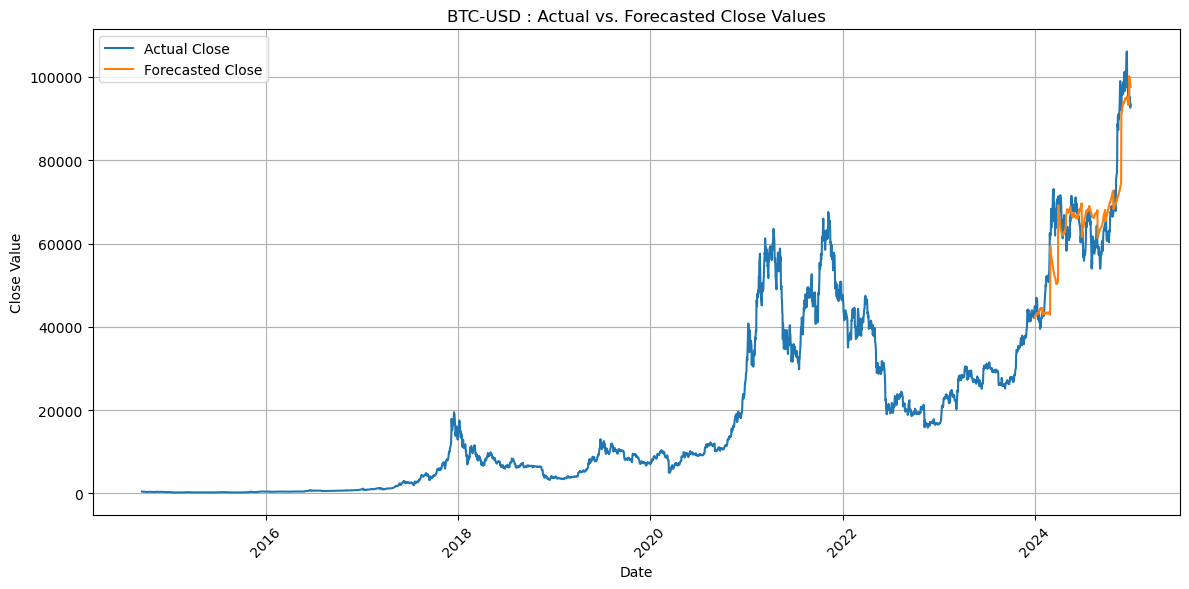

MAPE: 8.65673845902194
ME: 1181.6526425887978
MAE: 5763.259797643443
MPE: 0.9923575501394696
RMSE: 7723.16937019225
R: 0.8564575427176795
Scalar Product: 12411252.191299438
Return Score: 0.5095890410958904
Long Return: 0.6210526315789474
Short Return: 0.38857142857142857
Mean Directional Accuracy: 0.5095890410958904
Mean Directional Accuracy Positive: 0.6210526315789474
Mean Directional Accuracy Negative: 0.38857142857142857


In [114]:
forecast_crypto_prices(crypto_symbols, data_dir, train_end_date="2023-12-31", horizon = 30, freq='D', scaling = None)

Fetching 3 files: 100%|██████████████████████████████████████████████████████████████████████████| 3/3 [00:00<?, ?it/s]


Model used: TimesFmHparams(context_len=512, horizon_len=7, input_patch_len=32, output_patch_len=128, num_layers=20, num_heads=16, model_dims=1280, per_core_batch_size=32, backend='gpu', quantiles=(0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9), use_positional_embedding=True, point_forecast_mode='median')
Execution time for forecast_crypto_prices(): 77.89159727096558 seconds


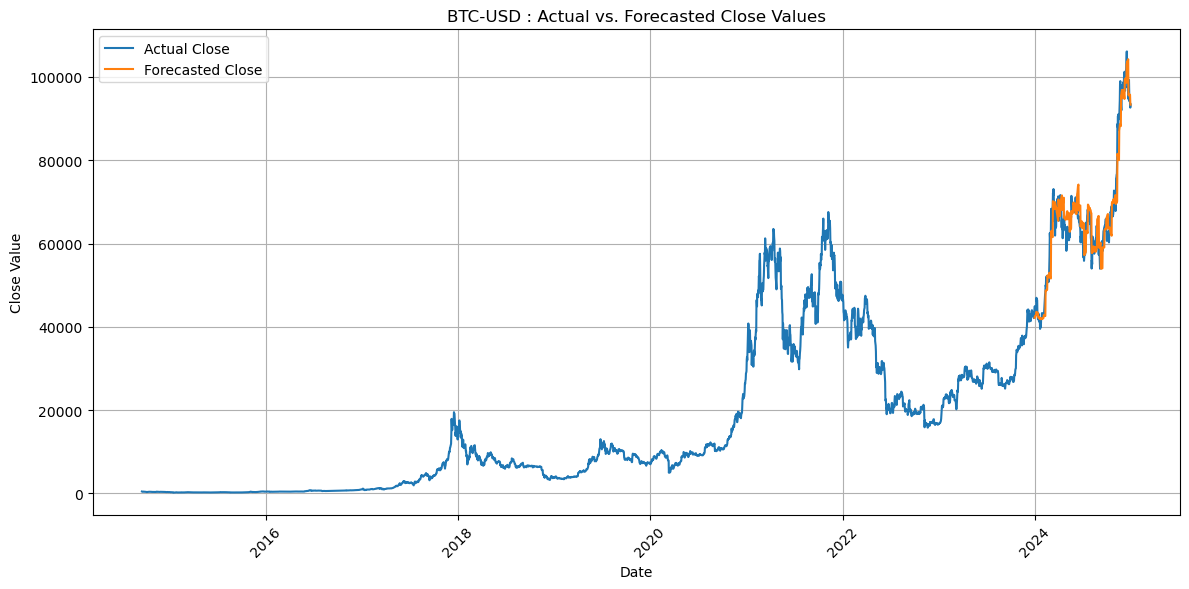

MAPE: 5.009032026690893
ME: 75.7272562329235
MAE: 3295.2363921618853
MPE: -0.09374805641369248
RMSE: 4176.62923331501
R: 0.9588759834291224
Scalar Product: 175626978.54187012
Return Score: 0.4986301369863014
Long Return: 0.5421052631578948
Short Return: 0.4514285714285714
Mean Directional Accuracy: 0.4986301369863014
Mean Directional Accuracy Positive: 0.5421052631578948
Mean Directional Accuracy Negative: 0.4514285714285714


In [115]:
forecast_crypto_prices(crypto_symbols, data_dir, train_end_date="2023-12-31", horizon = 7, freq='D', scaling = None)

Fetching 3 files: 100%|██████████████████████████████████████████████████████████████████████████| 3/3 [00:00<?, ?it/s]


Model used: TimesFmHparams(context_len=512, horizon_len=1, input_patch_len=32, output_patch_len=128, num_layers=20, num_heads=16, model_dims=1280, per_core_batch_size=32, backend='gpu', quantiles=(0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9), use_positional_embedding=True, point_forecast_mode='median')
Execution time for forecast_crypto_prices(): 513.0666041374207 seconds


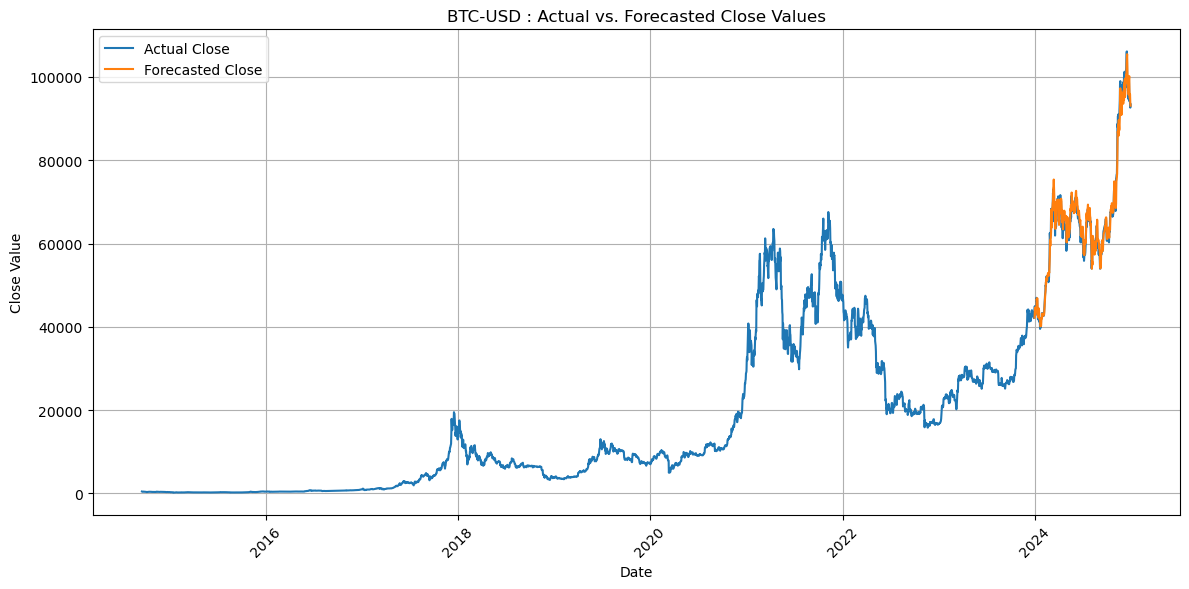

MAPE: 2.536360224535554
ME: -305.0040663422131
MAE: 1688.050685194672
MPE: -0.622267990202761
RMSE: 2211.5484455988394
R: 0.9889294433268574
Scalar Product: -22417878.208190918
Return Score: 0.4876712328767123
Long Return: 0.5157894736842106
Short Return: 0.45714285714285713
Mean Directional Accuracy: 0.4876712328767123
Mean Directional Accuracy Positive: 0.5157894736842106
Mean Directional Accuracy Negative: 0.45714285714285713


In [116]:
forecast_crypto_prices(crypto_symbols, data_dir, train_end_date="2023-12-31", horizon = 1, freq='D', scaling = None)